# SmartCare Hospital AI Coursework
## Task 07 — Explainable Artificial Intelligence

**Objective:** Explain the Task 05 selected model using validation data only. Global permutation importance shows general model dependence, while local sensitivity explains one representative patient prediction. Test data is not reused.

## 7.1 Import Libraries and Load Data

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
# Run Colab/VS Code from the cloned repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models_checkpoints'

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

metadata = json.loads((MODEL_DIR / 'selected_model_info.json').read_text())
model = joblib.load(MODEL_DIR / 'selected_model_pipeline.pkl')
X_train = pd.read_csv(MODEL_DIR / 'X_train.csv')
X_val = pd.read_csv(MODEL_DIR / 'X_val.csv')
y_val = pd.read_csv(MODEL_DIR / 'y_val.csv').iloc[:, 0]

assert X_train.columns.tolist() == metadata['feature_columns']
assert X_val.columns.tolist() == metadata['feature_columns']

print('Model explained:', metadata['selected_model'])
print('Training reference:', X_train.shape)
print('Validation explanation set:', X_val.shape)
print('Test data loaded: No')

Model explained: Random Forest
Training reference: (525, 24)
Validation explanation set: (175, 24)
Test data loaded: No


## 7.2 Global Permutation Importance

,Feature,Mean Importance,Standard Deviation
0,waiting_days,0.0576,0.0170
1,previous_appointments,0.0347,0.0153
2,appointment_month,0.0121,0.0141
3,appointment_dayofweek,0.0115,0.0161
4,age,0.0067,0.0146
5,department_General Medicine,0.0066,0.0042
6,diagnosis_Kidney Infection,0.0063,0.0048
7,department_Orthopedics,0.0059,0.0076
8,previous_admissions,0.0047,0.0097
9,department_Radiology,0.0040,0.0079


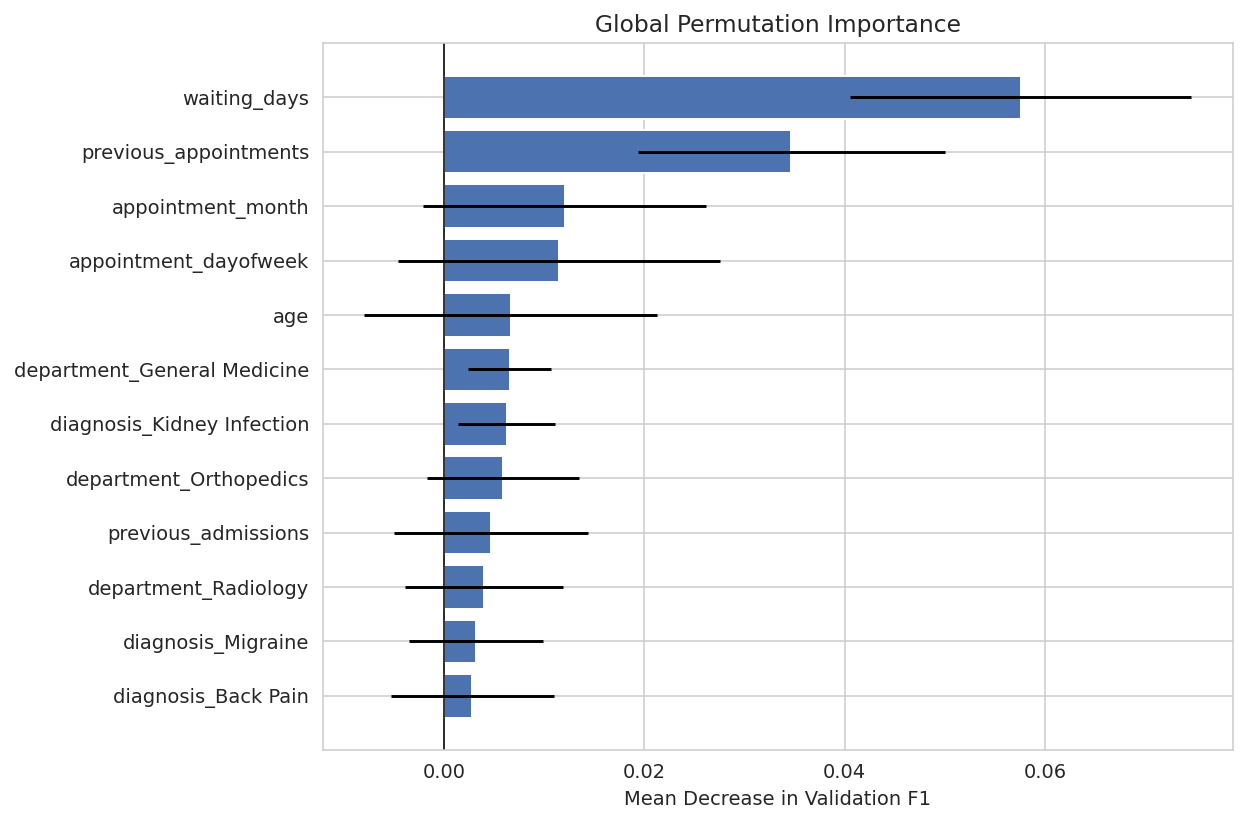

In [2]:
importance = permutation_importance(
    model, X_val, y_val,
    scoring='f1', n_repeats=30,
    random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Mean Importance': importance.importances_mean,
    'Standard Deviation': importance.importances_std
}).sort_values('Mean Importance', ascending=False).reset_index(drop=True)

display(importance_df.head(12).round(4))

top = importance_df.head(12).sort_values('Mean Importance')
plt.figure(figsize=(9, 6))
plt.barh(top['Feature'], top['Mean Importance'],
         xerr=top['Standard Deviation'], color='#4C72B0')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Mean Decrease in Validation F1')
plt.title('Global Permutation Importance')
plt.tight_layout()
plt.show()

**Interpretation:** A larger positive value means validation F1 decreases more when the feature is shuffled. Negative values are not evidence of usefulness. Importance shows model dependence, not causation, and correlated features may share importance.

## 7.3 Representative Patient-Level Explanation

In [3]:
validation_probability = model.predict_proba(X_val)[:, 1]
median_probability = np.median(validation_probability)
patient_position = int(np.argmin(np.abs(validation_probability - median_probability)))

patient = X_val.iloc[[patient_position]].copy()
patient_probability = float(validation_probability[patient_position])
reference_values = X_train.median(numeric_only=True)

local_rows = []
for feature in X_val.columns:
    changed = patient.copy()
    original_value = changed.iloc[0][feature]
    reference_value = reference_values[feature]
    changed.loc[:, feature] = reference_value
    changed_probability = float(model.predict_proba(changed)[:, 1][0])
    local_rows.append({
        'Feature': feature,
        'Patient Value': original_value,
        'Reference Value': reference_value,
        'Probability Contribution': patient_probability - changed_probability
    })

local_df = pd.DataFrame(local_rows)
local_df['Absolute Contribution'] = local_df['Probability Contribution'].abs()
local_df = local_df.sort_values('Absolute Contribution', ascending=False).reset_index(drop=True)

print('Validation row index:', X_val.index[patient_position])
print('Patient no-show probability:', round(patient_probability, 4))
display(local_df.head(10).round(4))

Validation row index: 15
Patient no-show probability: 0.6


,Feature,Patient Value,Reference Value,Probability Contribution,Absolute Contribution
0,missed_previous_appointments,2.0000,0.0,0.1100,0.1100
1,missed_ratio,0.3333,0.0,0.1067,0.1067
2,appointment_month,4.0000,6.0,0.0800,0.0800
3,has_missed_before,1.0000,0.0,0.0733,0.0733
4,previous_appointments,6.0000,3.0,-0.0667,0.0667
5,previous_admissions,0.0000,1.0,0.0600,0.0600
6,waiting_days,3.0000,22.0,0.0333,0.0333
7,appointment_dayofweek,1.0000,3.0,-0.0300,0.0300
8,department_Orthopedics,1.0000,0.0,-0.0200,0.0200
9,diagnosis_Kidney Infection,1.0000,0.0,0.0067,0.0067


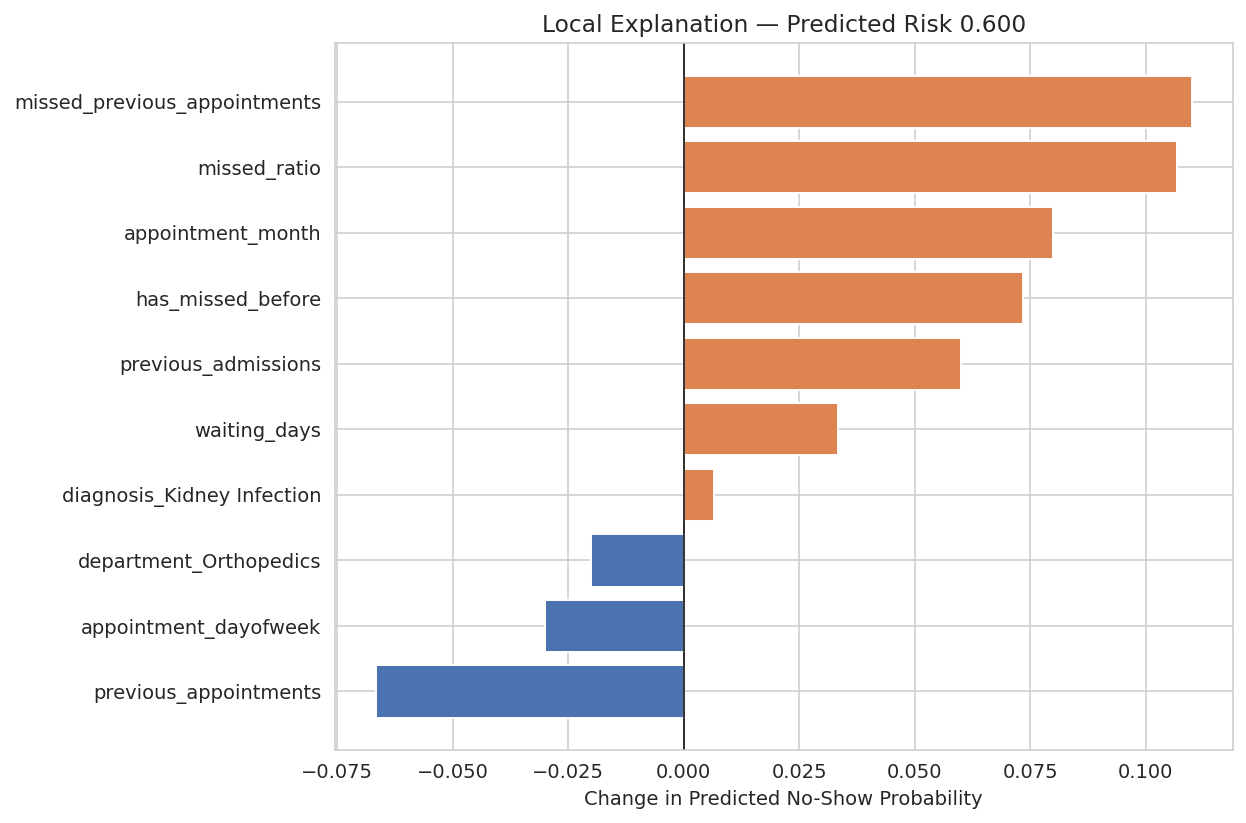

In [4]:
top_local = local_df.head(10).sort_values('Probability Contribution')
colors = ['#DD8452' if value > 0 else '#4C72B0'
          for value in top_local['Probability Contribution']]

plt.figure(figsize=(9, 6))
plt.barh(top_local['Feature'], top_local['Probability Contribution'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Change in Predicted No-Show Probability')
plt.title(f'Local Explanation — Predicted Risk {patient_probability:.3f}')
plt.tight_layout()
plt.show()

**Interpretation:** A positive contribution means the patient's value increased predicted no-show probability compared with the training median. A negative contribution means it reduced the probability. This is a local sensitivity explanation, not a causal claim.

## 7.4 Transparency, Fairness, and Ethical Use

- **Transparency:** Global and local explanations show how the saved pipeline uses its inputs.
- **Fairness:** Gender and age group are not model inputs. Task 06 monitors subgroup recall, false-positive rate, and calibration.
- **Privacy:** Patient identifiers and unnecessary clinical details are excluded.
- **Human oversight:** High risk should trigger a supportive reminder review, not cancellation or denial of care.
- **Limitations:** The dataset is small, performance is moderate, and explanations do not prove cause and effect.

## 7.5 Save Explainability Results

In [5]:
importance_df.to_csv(MODEL_DIR / 'task07_global_permutation_importance.csv', index=False)
local_df.to_csv(MODEL_DIR / 'task07_local_prediction_reasoning.csv', index=False)

report = [
    'SMARTCARE TASK 07 INTERPRETATION REPORT',
    f"Model: {metadata['selected_model']}",
    'Data: validation set only; test set not reused.',
    'Global method: permutation importance using F1-score.',
    'Local method: one-feature-at-a-time sensitivity against training medians.',
    'Top global features: ' + ', '.join(importance_df.head(5)['Feature']),
    f'Example patient probability: {patient_probability:.4f}',
    'Explanations describe model behaviour, not causation.'
]
(MODEL_DIR / 'task07_interpretation_report.txt').write_text('\n'.join(report))
print('Task 07 results saved successfully.')

Task 07 results saved successfully.


### Task 07 Summary

- Global permutation importance was calculated on validation data.
- A representative patient was selected using a documented median-risk rule.
- Positive and negative local contributions were explained clearly.
- Test data was not reused.
- Privacy, fairness, uncertainty, and human oversight were addressed.